Libraries Loaded
Datasets Loaded


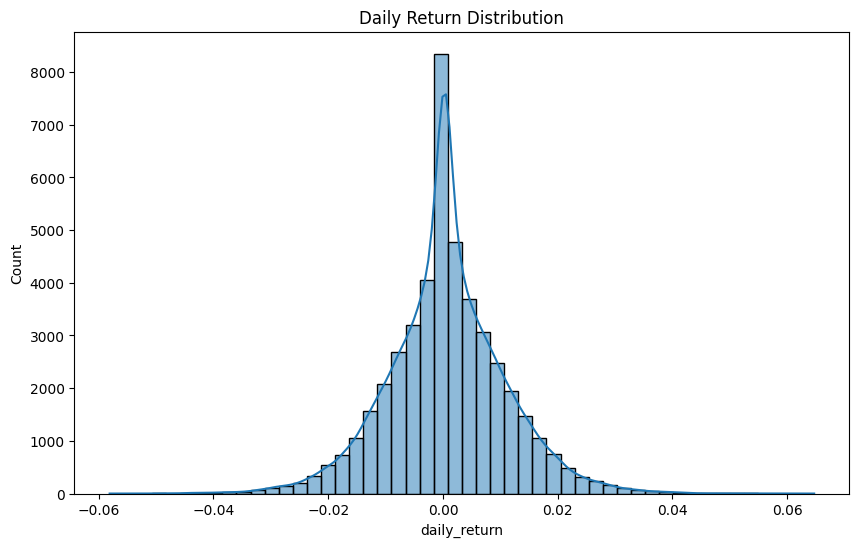

   amfi_code      cagr
0     100016  0.042505
1     100025  0.067323
2     100033  0.477924
3     101206  0.362911
4     101207  0.122635
   amfi_code  sharpe_ratio
0     100016     -0.201517
1     100025     -0.567095
2     100033      1.093699
3     101206      1.027213
4     101207      0.162661
   amfi_code  sortino_ratio
0     100016      -0.351047
1     100025      -0.941821
2     100033       1.829134
3     101206       1.799563
4     101207       0.276644
   amfi_code     alpha      beta
0     100016 -0.089699  0.788441
1     100025  0.033199  0.060713
2     100033  0.114423  0.991590
3     101206  0.097443  0.737015
4     101207 -0.350741  2.878184
   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469
    amfi_code      cagr  sharpe_ratio     alpha      beta  max_drawdown  \
34     148567  0.476017      1.448291  0.181968  0.557134     -0.112657   
30     120843  0.47547

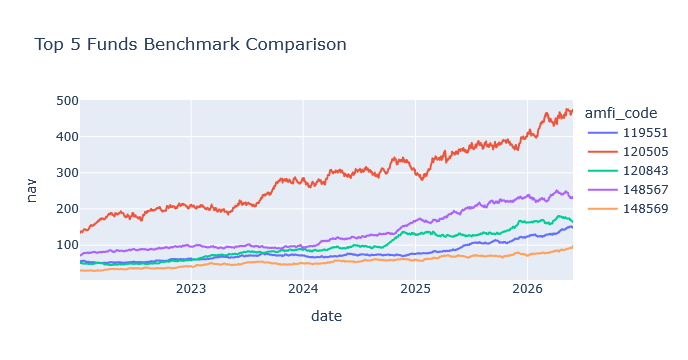

<Figure size 640x480 with 0 Axes>

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats

%matplotlib inline

print("Libraries Loaded")

nav_history = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)


fund_master = pd.read_csv(
    "../data/processed/clean_fund_master.csv"
)

scheme_performance = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

print("Datasets Loaded")
nav_history['date'] = pd.to_datetime(
    nav_history['date']
)
nav_history = nav_history.sort_values(
    by=['amfi_code', 'date']
)

nav_history['daily_return'] = nav_history.groupby(
    'amfi_code'
)['nav'].pct_change()
nav_history.dropna(inplace=True)
plt.figure(figsize=(10,6))

sns.histplot(
    nav_history['daily_return'],
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")

plt.show()
cagr_results = []

for fund in nav_history['amfi_code'].unique():

    fund_data = nav_history[
        nav_history['amfi_code'] == fund
    ]

    start_nav = fund_data['nav'].iloc[0]

    end_nav = fund_data['nav'].iloc[-1]

    years = 3

    cagr = (
        (end_nav / start_nav)
        **
        (1 / years)
    ) - 1

    cagr_results.append([fund, cagr])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=['amfi_code', 'cagr']
)

print(cagr_df.head())
risk_free_rate = 0.065

sharpe_results = []

for fund in nav_history['amfi_code'].unique():

    fund_data = nav_history[
        nav_history['amfi_code'] == fund
    ]

    mean_return = fund_data['daily_return'].mean()

    std_return = fund_data['daily_return'].std()

    sharpe = (
        (mean_return - risk_free_rate/252)
        /
        std_return
    ) * np.sqrt(252)

    sharpe_results.append([fund, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=['amfi_code', 'sharpe_ratio']
)

print(sharpe_df.head())
sortino_results = []

for fund in nav_history['amfi_code'].unique():

    fund_data = nav_history[
        nav_history['amfi_code'] == fund
    ]

    negative_returns = fund_data[
        fund_data['daily_return'] < 0
    ]['daily_return']

    downside_std = negative_returns.std()

    mean_return = fund_data['daily_return'].mean()

    sortino = (
        (mean_return - risk_free_rate/252)
        /
        downside_std
    ) * np.sqrt(252)

    sortino_results.append([fund, sortino])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=['amfi_code', 'sortino_ratio']
)

print(sortino_df.head())
market_return = nav_history.groupby(
    'date'
)['daily_return'].mean()

alpha_beta_results = []

for fund in nav_history['amfi_code'].unique():

    fund_data = nav_history[
        nav_history['amfi_code'] == fund
    ]

    merged = pd.merge(
        fund_data,
        market_return,
        on='date',
        suffixes=('_fund', '_market')
    )

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged['daily_return_market'],
        merged['daily_return_fund']
    )

    beta = slope

    alpha = intercept * 252

    alpha_beta_results.append([fund, alpha, beta])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=['amfi_code', 'alpha', 'beta']
)

print(alpha_beta_df.head())
drawdown_results = []

for fund in nav_history['amfi_code'].unique():

    fund_data = nav_history[
        nav_history['amfi_code'] == fund
    ].copy()

    fund_data['running_max'] = (
        fund_data['nav'].cummax()
    )

    fund_data['drawdown'] = (
        fund_data['nav']
        -
        fund_data['running_max']
    ) / fund_data['running_max']

    max_dd = fund_data['drawdown'].min()

    drawdown_results.append([fund, max_dd])

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=['amfi_code', 'max_drawdown']
)

print(drawdown_df.head())
scorecard = cagr_df.merge(
    sharpe_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    drawdown_df,
    on='amfi_code'
)
scorecard['score'] = (
    scorecard['cagr'] * 0.30
    +
    scorecard['sharpe_ratio'] * 0.25
    +
    scorecard['alpha'] * 0.20
    -
    abs(scorecard['max_drawdown']) * 0.10
)

scorecard = scorecard.sort_values(
    by='score',
    ascending=False
)

print(scorecard.head())
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)
top_funds = scorecard.head(5)['amfi_code']

benchmark_data = nav_history[
    nav_history['amfi_code'].isin(top_funds)
]

fig = px.line(
    benchmark_data,
    x='date',
    y='nav',
    color='amfi_code',
    title='Top 5 Funds Benchmark Comparison'
)

fig.show()
plt.savefig(
    "../reports/benchmark_comparison.png"
)